In [1]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import shap 
plt.style.use('default')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

C:\Users\i61815\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
url = "https://raw.githubusercontent.com/diplomadoequipo908-a11y/Proyecto-modulo-5/main/dataset.csv"
raw = pd.read_csv(url)
raw = raw.drop(columns=['Unnamed: 0'])
# Drop duplicates on track_id keep unique tracks.
df = raw.drop_duplicates(subset='track_id').copy().reset_index(drop=True)
print('Raw data:',raw.shape)
print('Unique tracks data:',df.shape)
df.describe()

Raw data: (114000, 20)
Unique tracks data: (89741, 20)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,33.198438,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,20.580824,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Data Dictionary
| Column | Type | Range | Description |
|---|---|---|---|
| `track_id` | String | — | Unique Spotify URI identifier for the track |
| `artists` | String | — | Performing artist name(s) |
| `album_name` | String | — | Album the track belongs to |
| `track_name` | String | — | Title of the track |
| `popularity` | Integer | 0 – 100 | Spotify popularity score (higher = more popular) |
| `duration_ms` | Integer | 0 – 5.2M | Track duration in milliseconds |
| `explicit` | Boolean | True/False | Whether the track has explicit lyrics |
| `danceability` | Float | 0.0 – 1.0 | How suitable a track is for dancing |
| `energy` | Float | 0.0 – 1.0 | Perceptual measure of intensity and activity |
| `key` | Integer | 0 – 11 | Musical key (0=C, 1=C♯, 2=D … 11=B) |
| `loudness` | Float | -49.5 – 4.5 | Overall loudness in decibels (dB) |
| `mode` | Integer | 0 or 1 | Modality — 1 = Major, 0 = Minor |
| `speechiness` | Float | 0.0 – 1.0 | Presence of spoken words in the track |
| `acousticness` | Float | 0.0 – 1.0 | Confidence the track is acoustic |
| `instrumentalness` | Float | 0.0 – 1.0 | Predicts whether a track has no vocals |
| `liveness` | Float | 0.0 – 1.0 | Detects presence of a live audience |
| `valence` | Float | 0.0 – 1.0 | Musical positiveness conveyed by the track |
| `tempo` | Float | 0 – 243 | Estimated tempo in beats per minute (BPM) |
| `time_signature` | Integer | 0 – 5 | Estimated time signature of the track |
| `track_genre` | String | 114 classes | Genre label assigned to the track |

## Null values

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


artists             1
album_name          1
track_name          1
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [4]:
# Fill null values
for col in ['track_name', 'album_name', 'artists']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


# Exploratory Data Analysis
## Popularity distribution

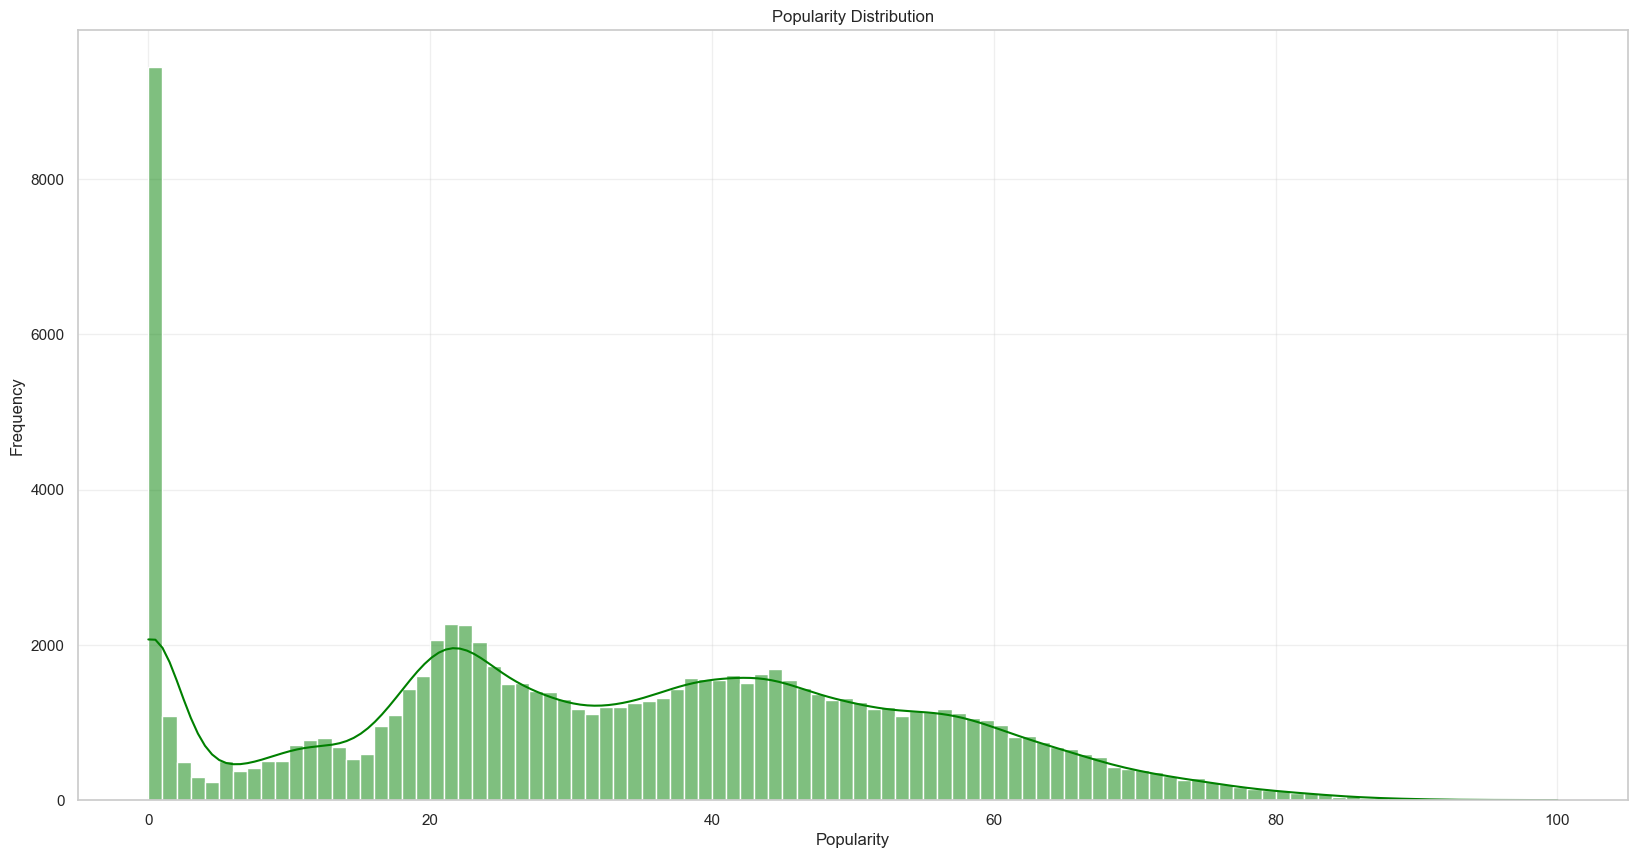

In [5]:
plt.figure(figsize=(20,10))
sns.histplot(df['popularity'], bins=100, kde=True,color='green')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [6]:
print(f"Mean: {df['popularity'].mean():.2f}")
print(f"Median: {df['popularity'].median():.2f}")
print(f"Skewness: {skew(df['popularity']):.3f}")

Mean: 33.20
Median: 33.00
Skewness: 0.071


##### Popularity is approximately symmetric and not dominated by extreme values

#### Popular vs unpopular songs

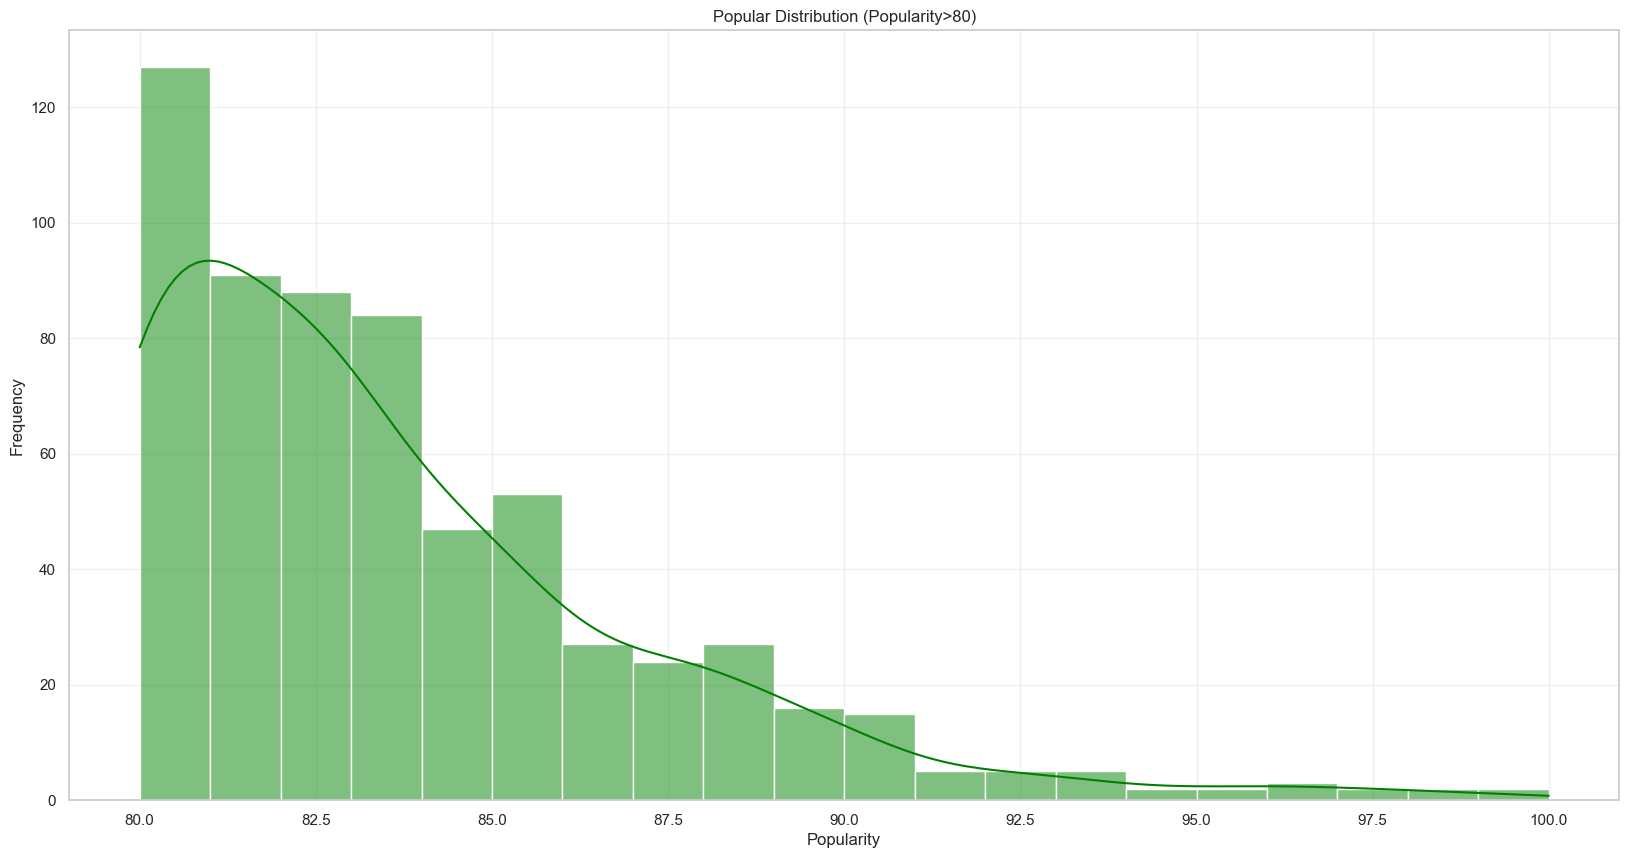

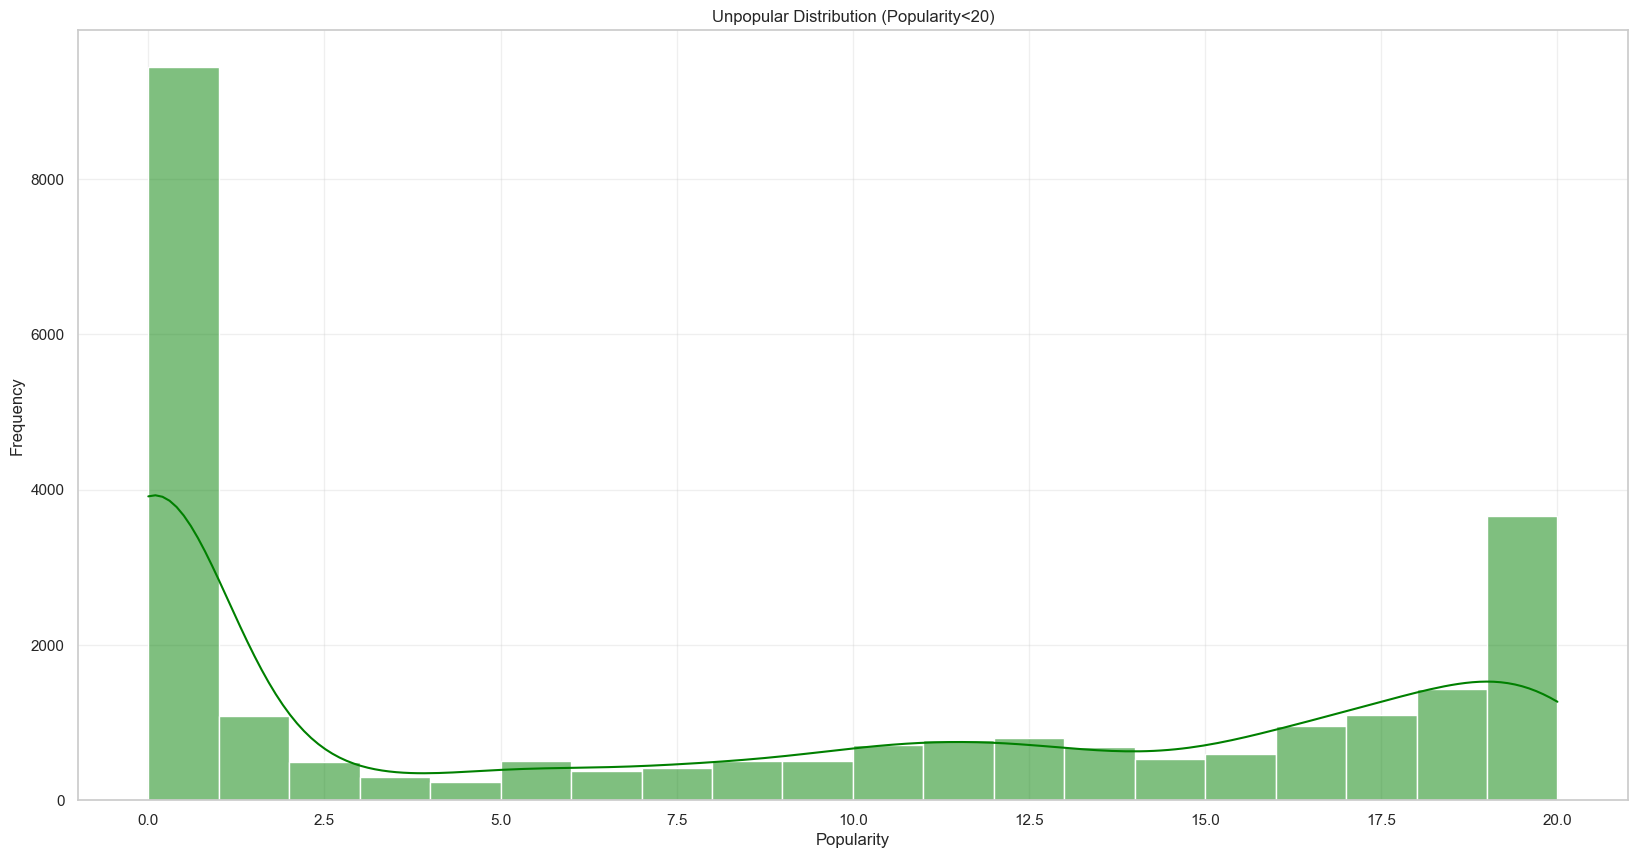

In [7]:
popular = df[df['popularity'] >= 80]

unpopular = df[df['popularity'] <= 20]

plt.figure(figsize=(20,10))
sns.histplot(popular['popularity'], bins=20, kde=True,color='green')
plt.title('Popular Distribution (Popularity>80)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(20,10))
sns.histplot(unpopular['popularity'], bins=20, kde=True,color='green')
plt.title('Unpopular Distribution (Popularity<20)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

## Top 20 genres

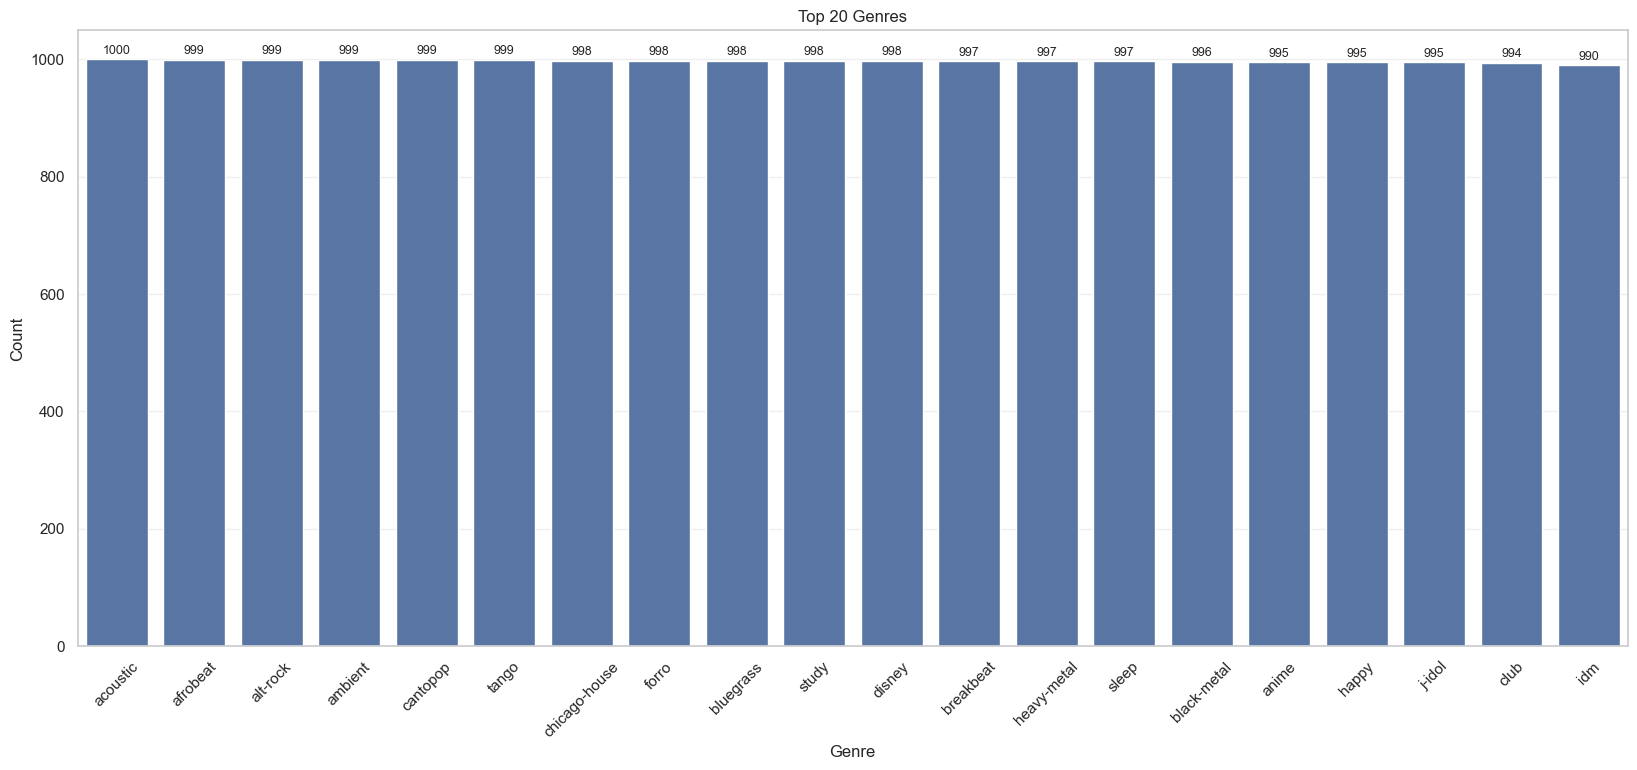

In [8]:
plt.figure(figsize=(20,8))
top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
)
ax = sns.barplot(x=top_genres.index,y=top_genres.values)

for i, v in enumerate(top_genres.values):
    ax.text(
        i,
        v + 10,
        str(v),
        ha='center',
        fontsize=9
    )

plt.title("Top 20 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Average popularity by genres

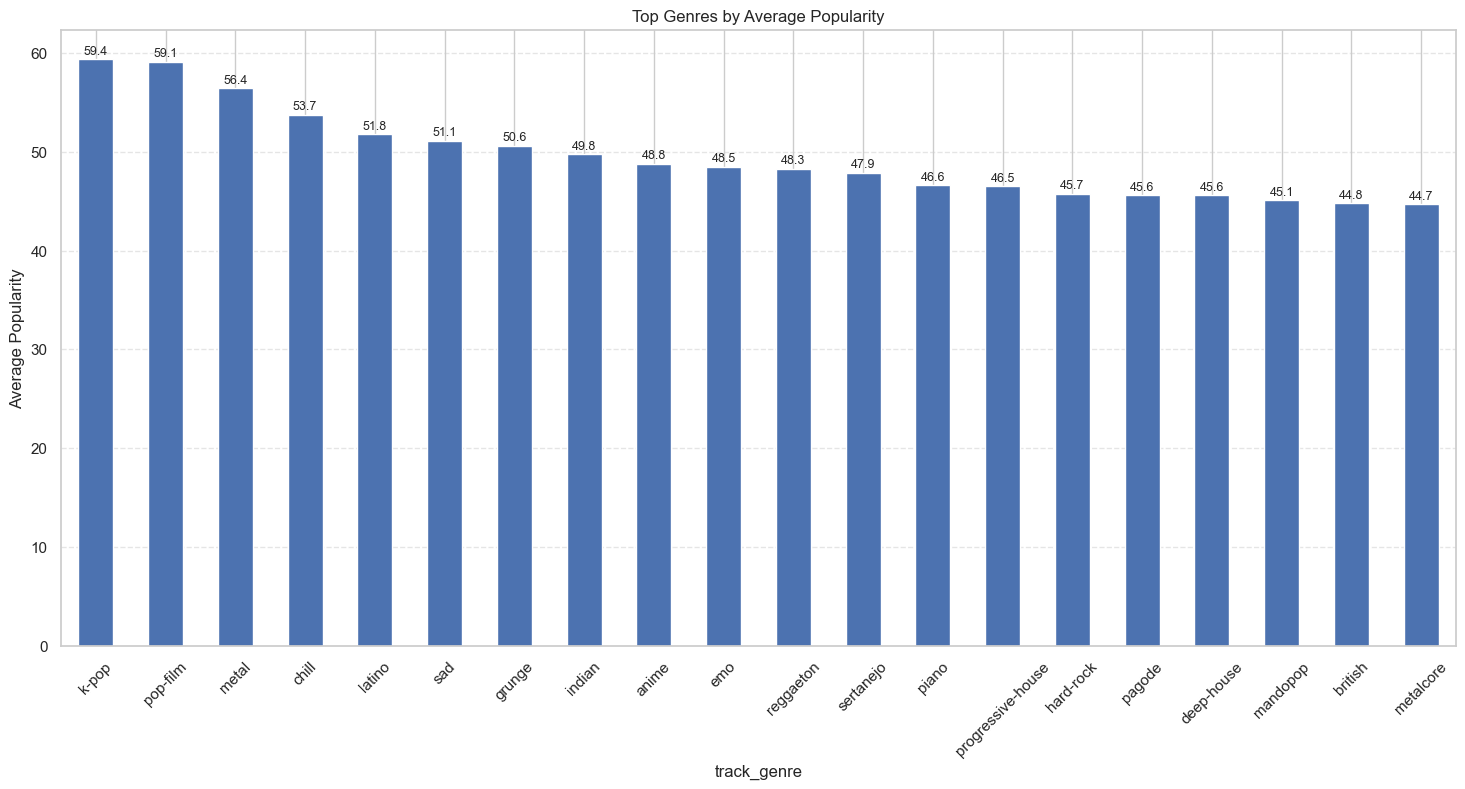

In [9]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
)

top_20 = genre_popularity.head(20)

plt.figure(figsize=(18,8))
ax = top_20.plot(kind='bar')
for i, v in enumerate(top_20.values):
    ax.text(
        i,
        v + 0.5,
        f'{v:.1f}',
        ha='center',
        fontsize=9
    )
plt.title("Top Genres by Average Popularity")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)
plt.show()

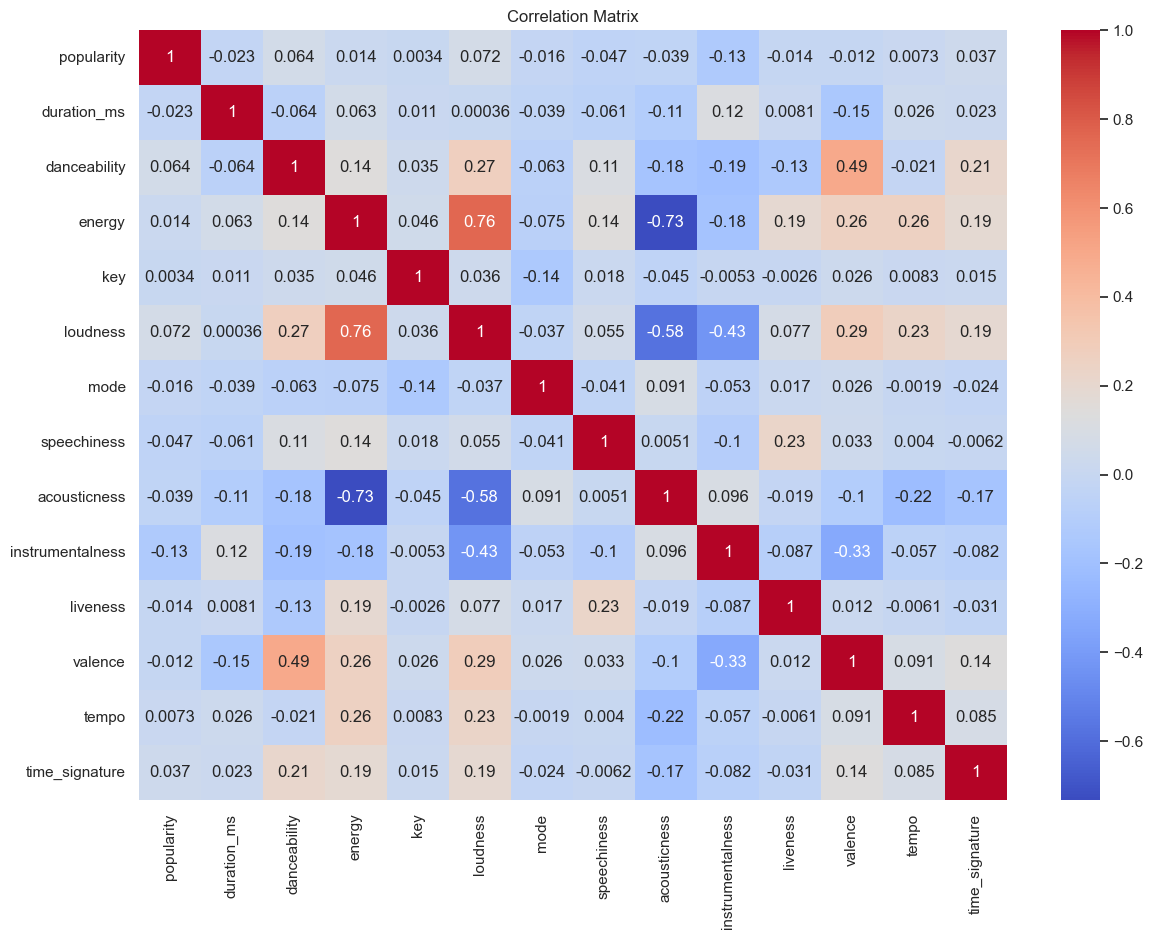

In [10]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

## Correlation with Popularity (Linear)

loudness            0.071676
danceability        0.064281
time_signature      0.036893
energy              0.013728
tempo               0.007270
key                 0.003432
valence            -0.011526
liveness           -0.013844
mode               -0.016214
duration_ms        -0.023119
acousticness       -0.038847
speechiness        -0.047081
instrumentalness   -0.127465
Name: popularity, dtype: float64


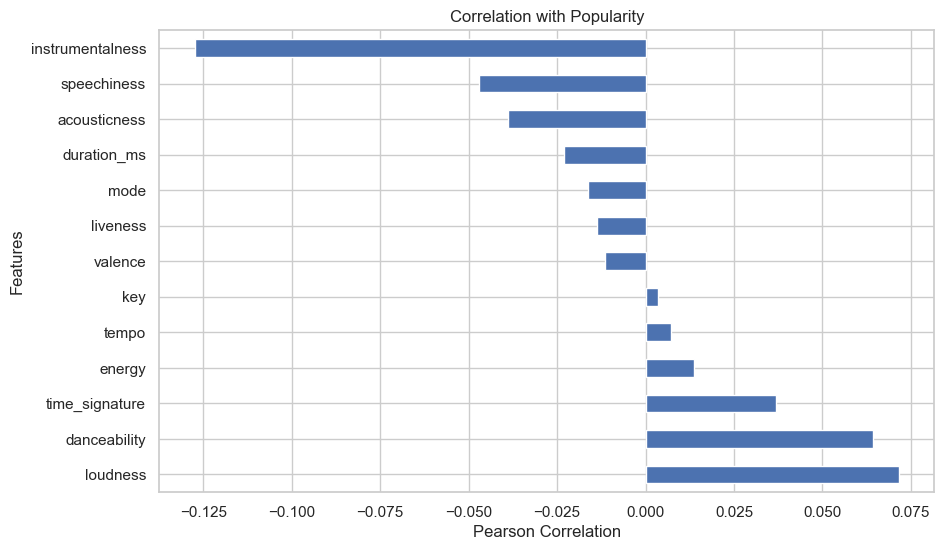

In [11]:
corr_popularity = (
    df.select_dtypes(include=np.number)
      .corr()['popularity']
      .drop('popularity')
      .sort_values(ascending=False)
)

print(corr_popularity)

plt.figure(figsize=(10,6))
corr_popularity.plot(kind='barh')
plt.title("Correlation with Popularity")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.show()

##### We can observe that there are no linear audio characteristics correlations with popularity. These findings suggest that popularity is likely driven by complex interactions among multiple audio characteristics and genre-specific effects. Consequently, a nonlinear modeling approach such as a Multilayer Perceptron (MLP) may be better suited to capture these relationships than traditional linear models.

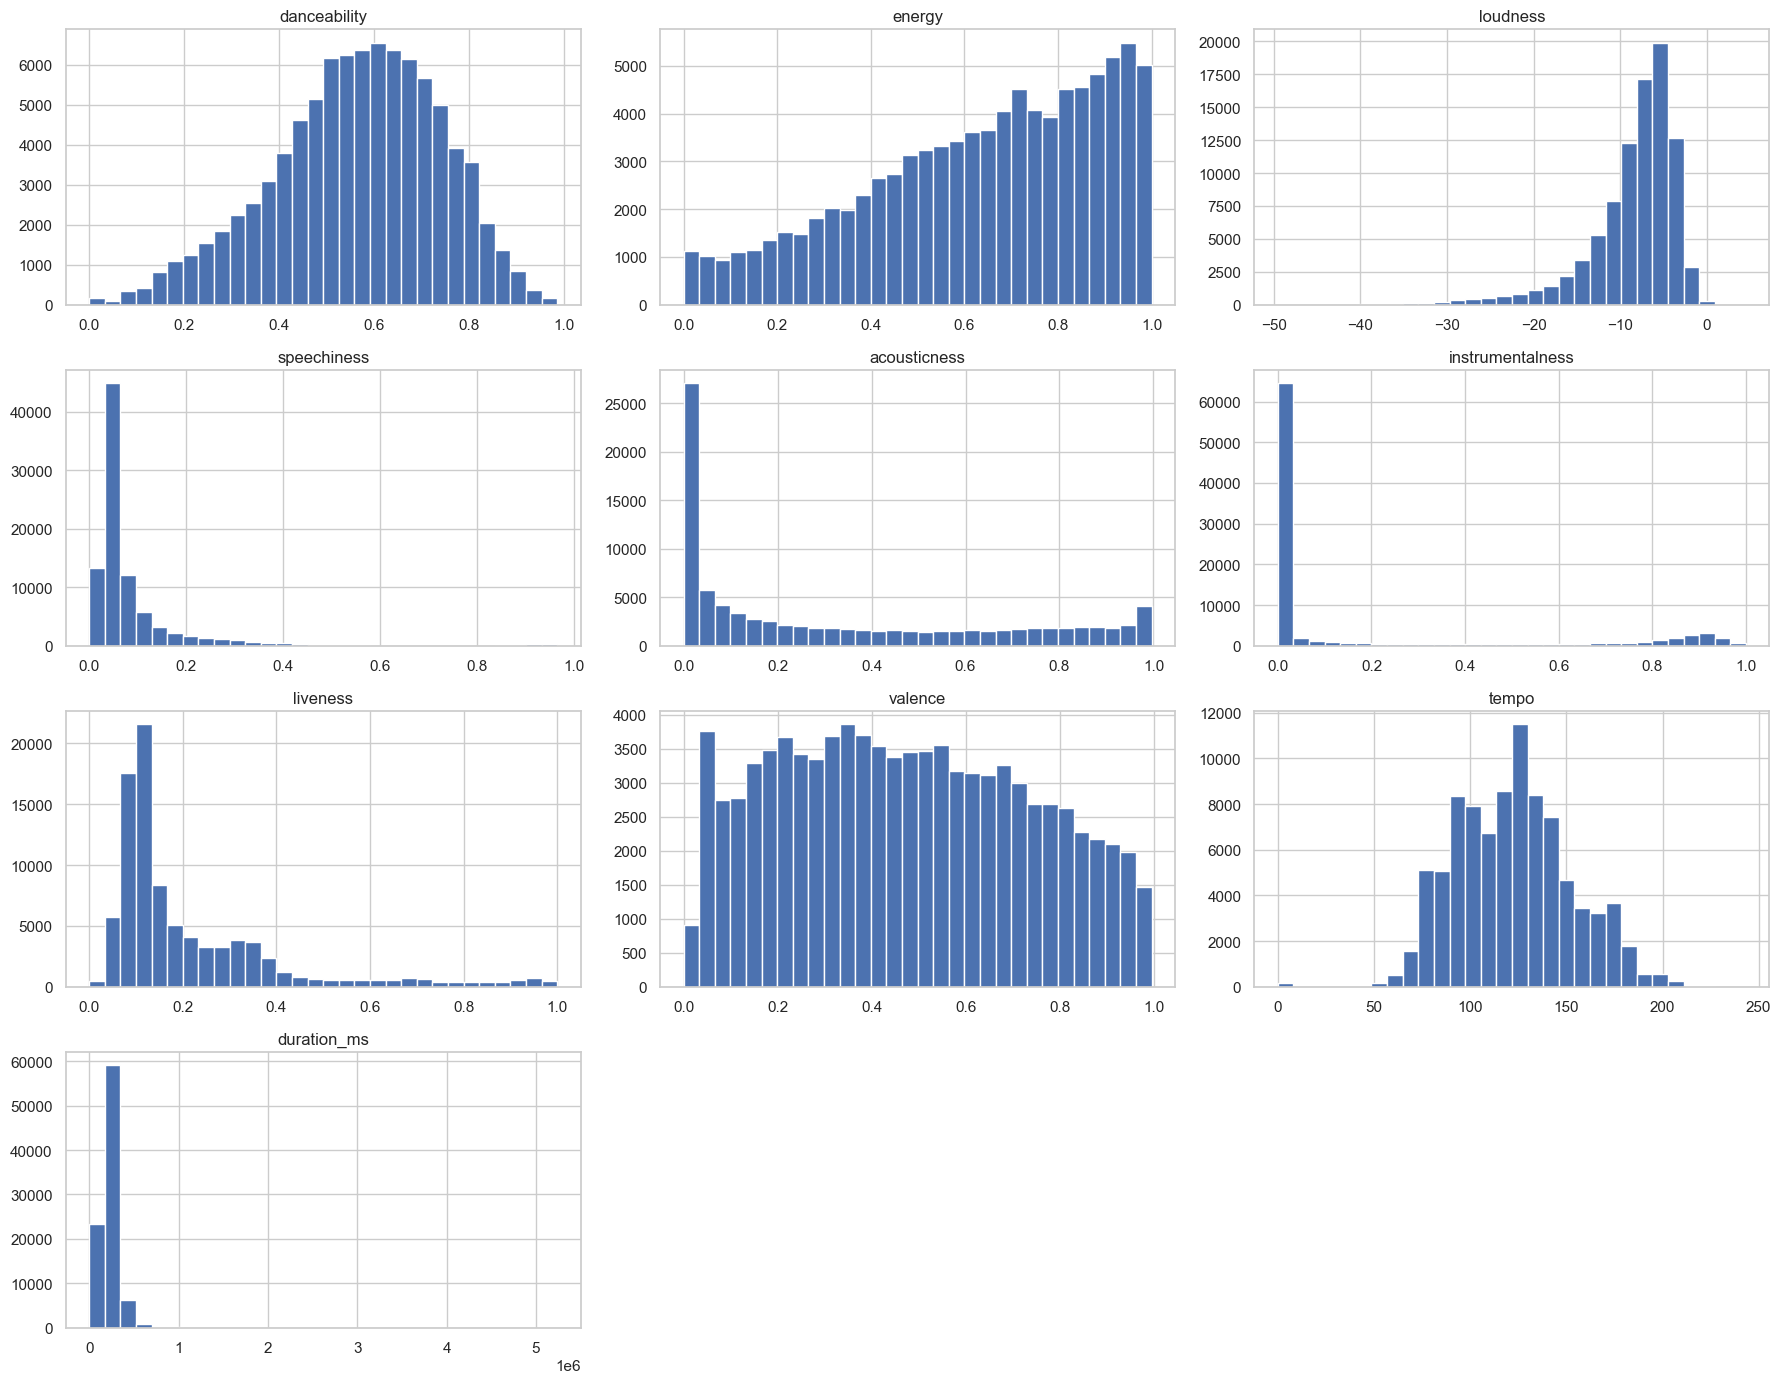

In [12]:
numeric_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

df[numeric_features].hist(
    bins=30,
    figsize=(18,14)
)

plt.tight_layout()

plt.show()

## Linear regression and Ridge, Lasso and ElasticNet


*** MODEL COMPARISON ***
              Model        MAE       RMSE        R2
0            Linear  11.994063  16.848371  0.320388
1             Ridge  11.997759  16.847880  0.320428
4  Polynomial_Ridge  12.041483  16.795977  0.324608
2             Lasso  12.198481  16.868165  0.318790
3        ElasticNet  13.286043  17.341489  0.280024


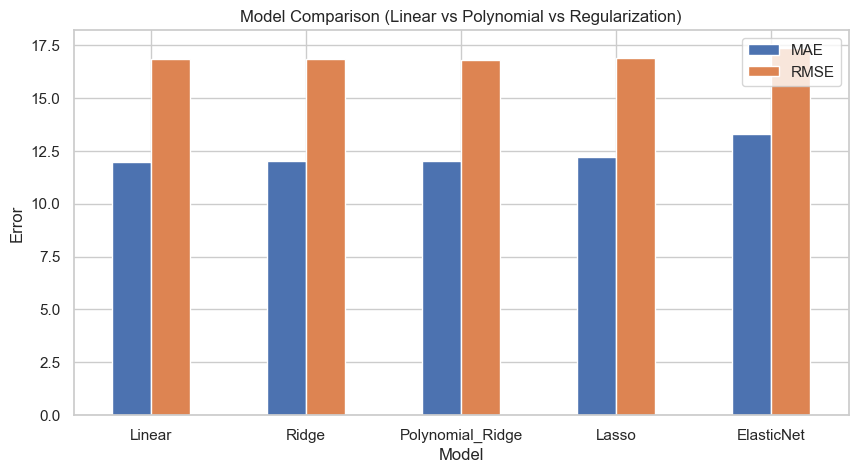


Best model: Linear


In [13]:

# Drop unnecessary cols
df_model = df.drop(columns=[
    'track_id',
    'track_name',
    'album_name',
    'artists',
    'time_signature'
])
# Format
df_model['explicit'] = df_model['explicit'].astype(int)
df_model['key'] = df_model['key'].astype(str)
df_model['duration_ms'] = np.log1p(df_model['duration_ms'])
# Features/target split
X = df_model.drop('popularity', axis=1)
y = df_model['popularity']

num_features = ['duration_ms','danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo']
cat_features = ['key','track_genre']

# Train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.20, random_state=42)

# Standard pipeline prepocessor
base_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

# Polynomial pipeline prepocessor
poly_num_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

poly_preprocessor = ColumnTransformer([
    ('num', poly_num_pipeline, num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

# Models
models = {
    'Linear': (base_preprocessor, LinearRegression()),
    'Ridge': (base_preprocessor, Ridge(alpha=1.0)),
    'Lasso': (base_preprocessor, Lasso(alpha=0.01, max_iter=10000)),
    'ElasticNet': (base_preprocessor, ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)),
    'Polynomial_Ridge': (poly_preprocessor, Ridge(alpha=10.0))
}

# Train
results = []

for name, (prep, model) in models.items():

    pipe = Pipeline([
        ('prep', prep),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })

results = pd.DataFrame(results).sort_values('MAE')

print("\n*** MODEL COMPARISON ***")
print(results)

# Plot
results.set_index('Model')[['MAE','RMSE']].plot(kind='bar',figsize=(10,5))
plt.title('Model Comparison (Linear vs Polynomial vs Regularization)')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()

# Best model
best_name = results.iloc[0]['Model']
best_prep, best_model = models[best_name]

best_pipe = Pipeline([
    ('prep', best_prep),
    ('model', best_model)
])

best_pipe.fit(X_train, y_train)
print(f"\nBest model: {best_name}")


##### From the analysis, acoustic features alone have limited ability to explain song popularity. The correlation matrix shows that all relationships between individual features and popularity are very weak, which indicates that popularity is not driven by any single measurable audio characteristic. 
##### Across the models tested, Ridge regression consistently performed slightly better than Lasso and ElasticNet. This outcome aligns with the structure of the data, where many features are strongly correlated with each other. Ridge handles this multicollinearity more effectively by distributing importance across correlated variables, rather than eliminating them as Lasso does. ElasticNet, which combines both approaches, did not provide additional benefit in this case.
##### Feature engineering, including interaction terms and nonlinear transformations, resulted in only marginal improvements. This suggests that the limitation is not the absence of simple transformations, but rather that the relationship between the inputs and the target is inherently complex. Linear models, even when enhanced, are reaching their performance limit on this dataset.
##### The overall performance, with an R² of around 0.22, indicates that a large portion of the variability in popularity remains unexplained. This is expected, as popularity is influenced by many external factors that are not present in the dataset, such as artist recognition, marketing, timing, and exposure.
##### At this stage, further tuning of linear models or additional feature engineering is unlikely to produce meaningful improvements. The results indicate that the problem is not under-optimized, but under-modeled. The next logical step is to move toward more flexible nonlinear models, such as gradient boosting or neural networks, which are better suited to capture complex interactions and patterns in this type of data.

### XGBoost


***
WITH GENRE
***
Best Iteration: 3383
MAE Test: 10.0095
R² Test: 0.4541

Top 15 SHAP Features
                          Feature  Importance
71       cat__track_genre_iranian   14.776326
105      cat__track_genre_romance    9.145441
133   remainder__instrumentalness    6.808949
83         cat__track_genre_metal    5.676136
113        cat__track_genre_sleep    5.658881
15   cat__track_genre_alternative    5.652368
77         cat__track_genre_k-pop    5.363573
101    cat__track_genre_reggaeton    4.876214
128             remainder__energy    4.673310
68         cat__track_genre_indie    4.515646
69     cat__track_genre_indie-pop    4.476370
80        cat__track_genre_latino    4.420021
32         cat__track_genre_dance    4.364206
93      cat__track_genre_pop-film    4.358459
102         cat__track_genre_rock    4.276646


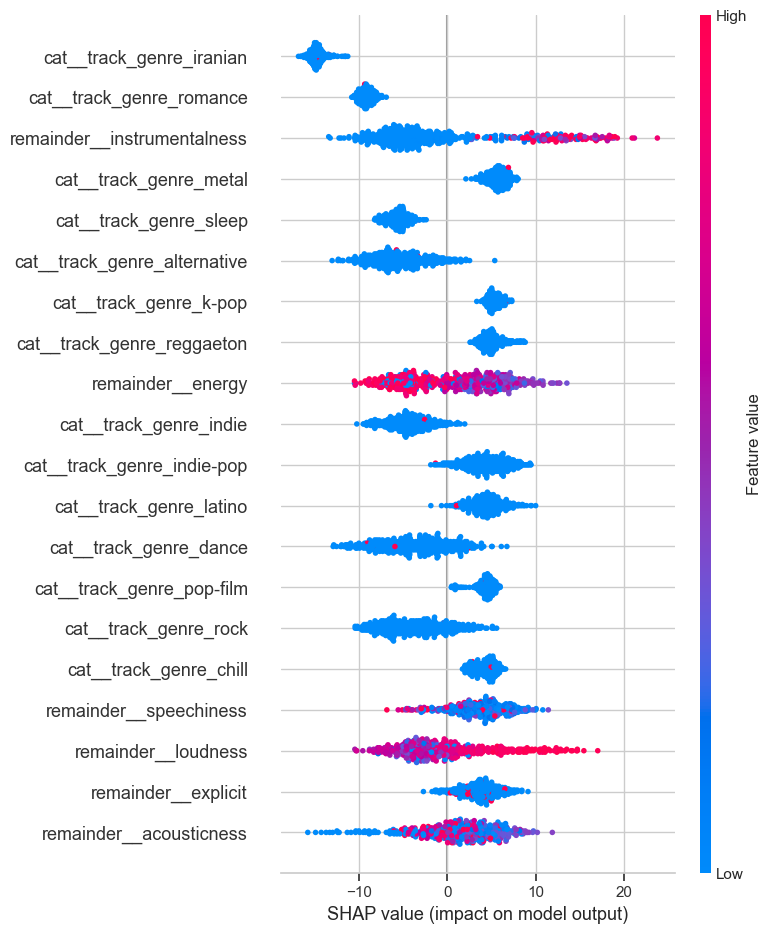

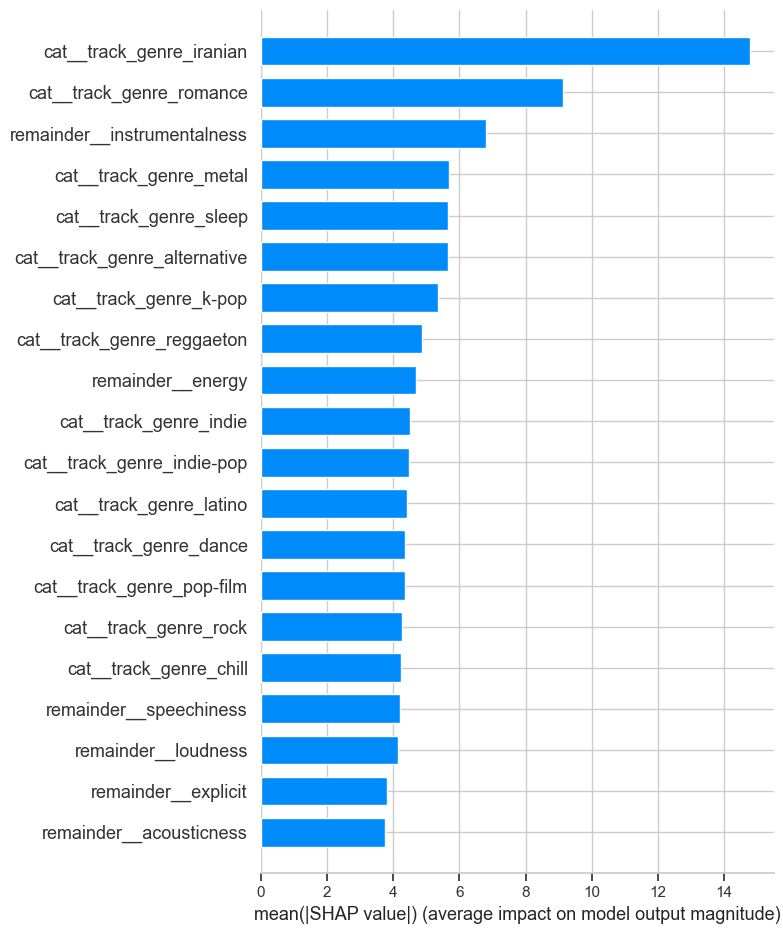


***
WITHOUT GENRE
***
Best Iteration: 2462
MAE Test: 13.8549
R² Test: 0.2118

Top 15 SHAP Features
                        Feature  Importance
19      remainder__acousticness    1.980406
20  remainder__instrumentalness    1.936764
22           remainder__valence    1.761712
14      remainder__danceability    1.701045
12       remainder__duration_ms    1.609030
15            remainder__energy    1.548901
18       remainder__speechiness    1.464871
16          remainder__loudness    1.274708
21          remainder__liveness    1.149944
23             remainder__tempo    1.098369
13          remainder__explicit    0.602395
17              remainder__mode    0.312180
0                    cat__key_0    0.184251
9                    cat__key_7    0.171338
1                    cat__key_1    0.137083


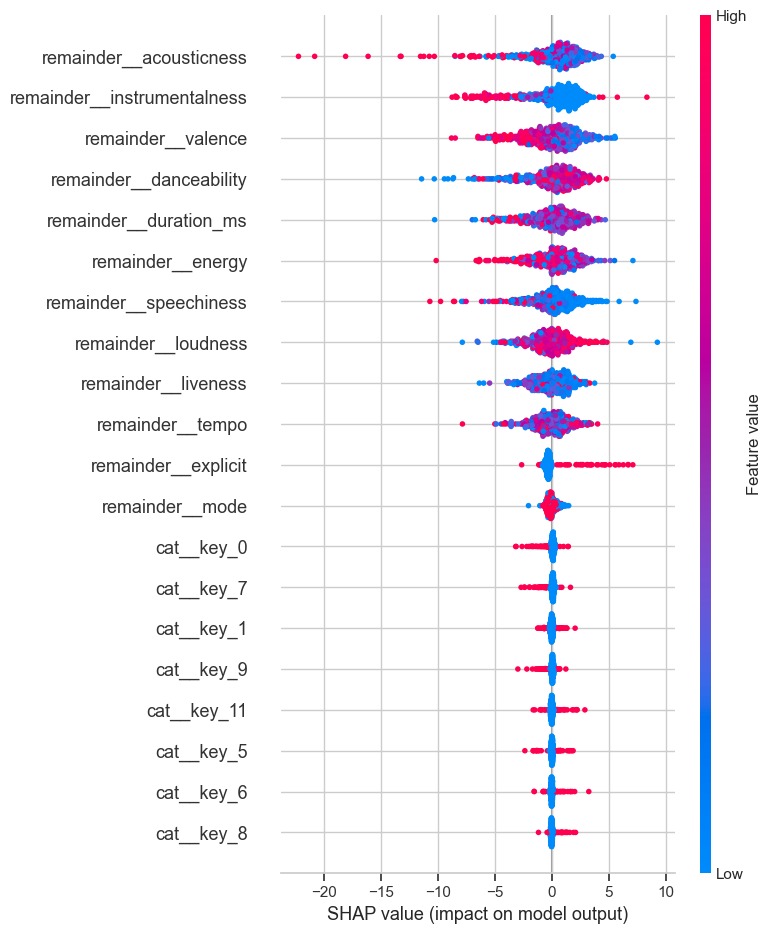

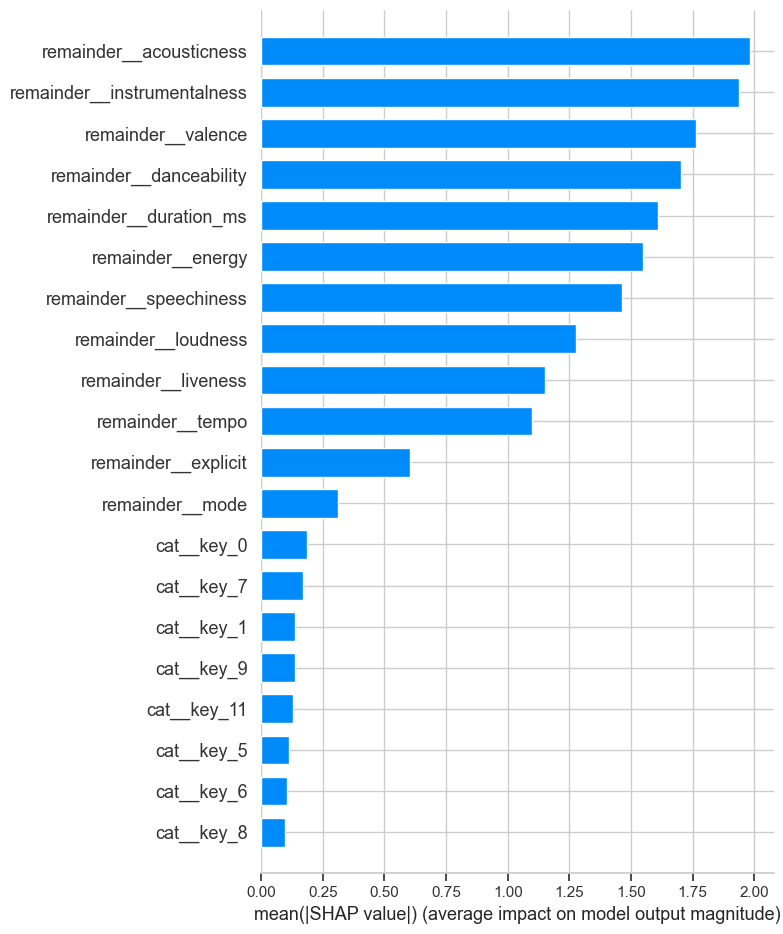


***
MODEL COMPARISON
***
           Model  Best_Iteration   MAE_Test   R2_Test
0     With Genre            3383  10.009479  0.454055
1  Without Genre            2462  13.854874  0.211769


In [15]:
# Two configurations for xgboost so genre can be evaluated 
configs = {
    'With Genre': ['key', 'track_genre'],
    'Without Genre': ['key']
}

results = []

for model_name, cat_features_current in configs.items():

    print(f'\n{"***"}')
    print(model_name.upper())
    print(f'{"***"}')

    if model_name == 'Without Genre':
        X_train_model = X_train.drop(columns='track_genre')
        X_val_model = X_val.drop(columns='track_genre')
        X_test_model = X_test.drop(columns='track_genre')
    else:
        X_train_model = X_train.copy()
        X_val_model = X_val.copy()
        X_test_model = X_test.copy()

    preprocessor = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore'), cat_features_current)],
        remainder='passthrough'
    )

    X_train_enc = preprocessor.fit_transform(X_train_model)
    X_val_enc = preprocessor.transform(X_val_model)
    X_test_enc = preprocessor.transform(X_test_model)

    model = XGBRegressor(
        objective='reg:squarederror',
        eval_metric='mae',
        n_estimators=5000,
        max_depth=8,
        learning_rate=0.03,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1,
        reg_alpha=0,
        early_stopping_rounds=30,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_enc,
        y_train,
        eval_set=[(X_val_enc, y_val)],
        verbose=False
    )

    test_preds = model.predict(X_test_enc)

    mae = mean_absolute_error(y_test, test_preds)
    r2 = r2_score(y_test, test_preds)

    results.append({
        'Model': model_name,
        'Best_Iteration': model.best_iteration,
        'MAE_Test': mae,
        'R2_Test': r2
    })

    print(f'Best Iteration: {model.best_iteration}')
    print(f'MAE Test: {mae:.4f}')
    print(f'R² Test: {r2:.4f}')

    feature_names = preprocessor.get_feature_names_out()

    sample_size = min(500, X_test_enc.shape[0])

    idx = np.random.RandomState(42).choice(
        X_test_enc.shape[0],
        sample_size,
        replace=False
    )

    X_sample = X_test_enc[idx]

    if hasattr(X_sample, 'toarray'):
        X_sample = X_sample.toarray()

    X_sample = pd.DataFrame(
        X_sample,
        columns=feature_names
    )

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    shap_importance = (
        pd.DataFrame({
            'Feature': feature_names,
            'Importance': np.abs(shap_values).mean(axis=0)
        })
        .sort_values('Importance', ascending=False)
    )

    print('\nTop 15 SHAP Features')
    print(shap_importance.head(15))

    shap.summary_plot(
        shap_values,
        X_sample,
        show=True
    )

    shap.summary_plot(
        shap_values,
        X_sample,
        plot_type='bar',
        show=True
    )

comparison = (
    pd.DataFrame(results)
    .sort_values('MAE_Test')
)


print(f'\n{"***"}')
print('MODEL COMPARISON')
print(f'{"***"}')
print(comparison)

##### The results show that genre plays a critical role in explaining a song's popularity. When genre information was included, the model's predictive performance improved substantially, suggesting that listener preferences are heavily influenced by the type of music being consumed. This makes sense, as genres capture factors that go beyond audio characteristics alone, such as audience size, cultural trends, and market demand. While genre was the strongest predictor, audio features like instrumentalness and energy also contributed meaningfully to the model, indicating that a song's musical characteristics still influence its success. Overall, the findings suggest that popularity is shaped by a combination of genre-level preferences and song-specific attributes, with genre providing the broader context and audio features helping explain why some tracks perform better than others within that context.
